In [1]:
import os
import sys
src_dir = os.path.join(os.getcwd(), '..', 'src' )
sys.path.append(src_dir)
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from etl.etl import ETL

In [2]:
train = pd.read_csv('train.csv')
train

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,city
0,2013-01-02,0,59,22154,999.00,1.0,явление 2012 bd,37,Кино - Blu-Ray,ярославль тц альтаир,ярославль
1,2013-01-03,0,25,2552,899.00,1.0,deep purple the house of blue light lp,58,Музыка - Винил,москва трк атриум,москва
2,2013-01-06,0,25,2554,1709.05,1.0,deep purple who do you think we are lp,58,Музыка - Винил,москва трк атриум,москва
3,2013-01-15,0,25,2555,1099.00,1.0,deep purple 30 very best of 2cd фирм,56,Музыка - CD фирменного производства,москва трк атриум,москва
4,2013-01-10,0,25,2564,349.00,1.0,deep purple perihelion live in concert dvd кир,59,Музыка - Музыкальное видео,москва трк атриум,москва
...,...,...,...,...,...,...,...,...,...,...,...
3127514,2015-10-10,33,25,7409,299.00,1.0,va nu jazz selection digipack,55,Музыка - CD локального производства,москва трк атриум,москва
3127515,2015-10-09,33,25,7460,299.00,1.0,va the golden jazz collection 1 2cd,55,Музыка - CD локального производства,москва трк атриум,москва
3127516,2015-10-14,33,25,7459,349.00,1.0,va the best of the 3 tenors,55,Музыка - CD локального производства,москва трк атриум,москва
3127517,2015-10-22,33,25,7440,299.00,1.0,va relax collection planet mp3 mp3cd jewel,57,Музыка - MP3,москва трк атриум,москва


In [3]:
train['date'] = pd.to_datetime(train['date'])
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['week'] = train['date'].dt.isocalendar().week
train['day_of_week'] = train['date'].dt.day_of_week
train['period'] = train['year'].astype(str) + '-' + train['month'].astype(str).str.zfill(2)
train


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,city,year,month,week,day_of_week,period
0,2013-01-02,0,59,22154,999.00,1.0,явление 2012 bd,37,Кино - Blu-Ray,ярославль тц альтаир,ярославль,2013,1,1,2,2013-01
1,2013-01-03,0,25,2552,899.00,1.0,deep purple the house of blue light lp,58,Музыка - Винил,москва трк атриум,москва,2013,1,1,3,2013-01
2,2013-01-06,0,25,2554,1709.05,1.0,deep purple who do you think we are lp,58,Музыка - Винил,москва трк атриум,москва,2013,1,1,6,2013-01
3,2013-01-15,0,25,2555,1099.00,1.0,deep purple 30 very best of 2cd фирм,56,Музыка - CD фирменного производства,москва трк атриум,москва,2013,1,3,1,2013-01
4,2013-01-10,0,25,2564,349.00,1.0,deep purple perihelion live in concert dvd кир,59,Музыка - Музыкальное видео,москва трк атриум,москва,2013,1,2,3,2013-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3127514,2015-10-10,33,25,7409,299.00,1.0,va nu jazz selection digipack,55,Музыка - CD локального производства,москва трк атриум,москва,2015,10,41,5,2015-10
3127515,2015-10-09,33,25,7460,299.00,1.0,va the golden jazz collection 1 2cd,55,Музыка - CD локального производства,москва трк атриум,москва,2015,10,41,4,2015-10
3127516,2015-10-14,33,25,7459,349.00,1.0,va the best of the 3 tenors,55,Музыка - CD локального производства,москва трк атриум,москва,2015,10,42,2,2015-10
3127517,2015-10-22,33,25,7440,299.00,1.0,va relax collection planet mp3 mp3cd jewel,57,Музыка - MP3,москва трк атриум,москва,2015,10,43,3,2015-10


# 1. General Distributions

## 1.1 *item_cnt_day* distribution

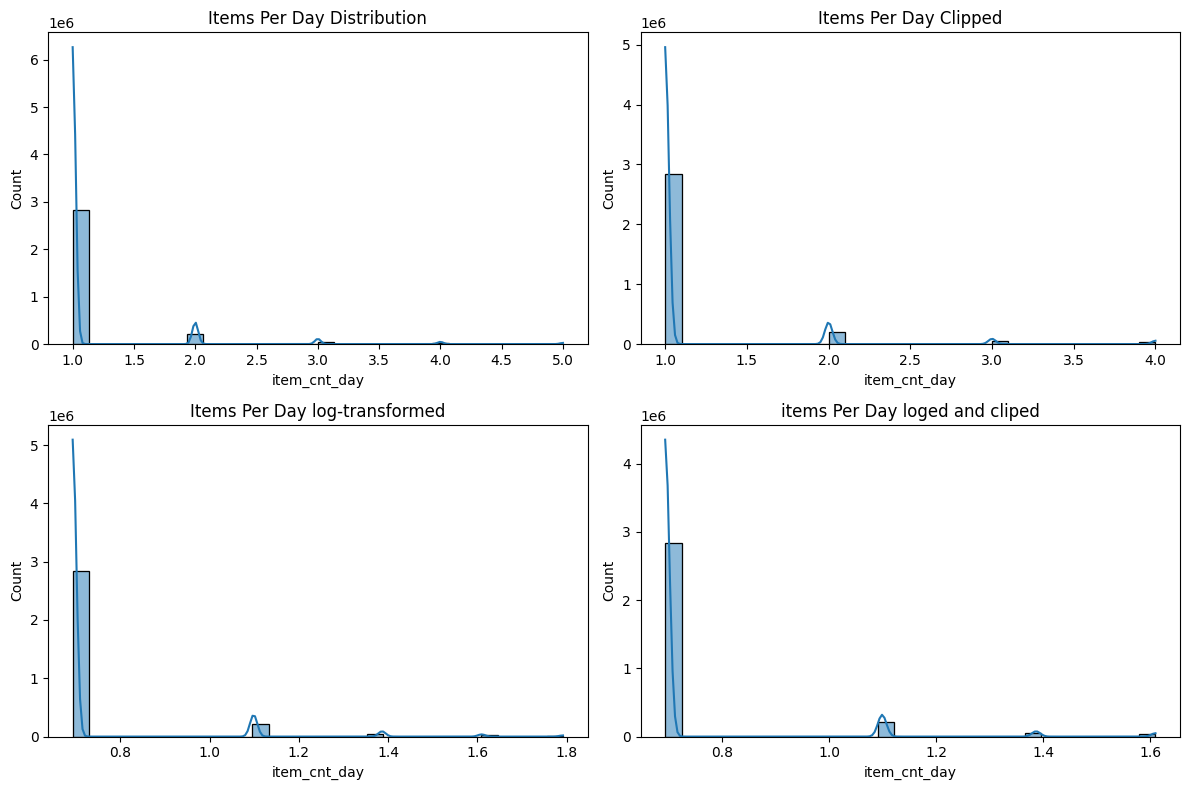

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize = (12,8))

sns.histplot(train['item_cnt_day'], bins=30, ax=axes[0,0], kde=True)
axes[0,0].set_title('Items Per Day Distribution')

upper_bound = train['item_cnt_day'].quantile(0.99)

sns.histplot(train['item_cnt_day'].clip(0, upper_bound), bins=30, ax=axes[0,1], kde=True)
axes[0,1].set_title('Items Per Day Clipped')

sns.histplot(np.log1p(train['item_cnt_day']), bins=30, ax=axes[1,0], kde=True)
axes[1,0].set_title('Items Per Day log-transformed')

sns.histplot(np.log1p(train['item_cnt_day'].clip(0, upper_bound)), bins=30, ax=axes[1,1], kde=True)
axes[1,1].set_title('items Per Day loged and cliped')

plt.tight_layout()
plt.show()

Observations:
- General *item_cnt_day* distribution doesn't seem to be very informative, though we can see that it is extremelly skewed. Most of items are sold less than ~50 units per day and there's a long tail up to more than 2000 units per day. What we can learn is that perhaps there are special days when sales go extremely up(like promotions, discounts or holidays)
- The idea is to clip the data to high upper bound percentile(99%). From here we learn that mostly items are sold 1 unit per day (around 2.7kk entries), nevertheless we have those items with zero-sells, an amount of items sold twice a day (around 200k entries) and very few items sold >3 units per day. The main conclusion is that the most common transactions are 1 item per day.
- Let's try log-transformation. This is done to compress the difference between qunatity of items sold. In normal representation the difference between 1 item per day and 2000 items per day is 1999, but after log-transformation the difference is ~7.60. From here we learn that the most common logarithm is in range (0,1), this means that most of items are sold less then 2.7 units per day. Though it's a little peak at log value a bit more than 1, representing those items sold about 3 units a day.
- The last but not least is using both log-transformation and cliping. The most common logarithm is nearly 0.75, which says that items are usually sold 2 units per day. There's also a little peak at logarithm of about 1.1, representing items sold 3 units per day.

From here we can make a general conclusion - mostly items are sold 1-3 units per day. Nevertheless there are those which are not sold at all and those sold in extremely high amounts (may be holidays or whatever)



**Feature Engineering Ideas**
- Since we saw really large values of *item_cnt_day* (~2000) it makes sense to standardize this feature. The idea coming to my mind is to log-transform and then scale to [0,1] range (via MinMaxScaler or StandardScaler). This way the model would not try to figure out those extreme sales and will be prevented from overfiting. Moreover tree-like models and neural networks are more preferable to be trained on scaled data.
- Also I guess some time-series analysis will help figure out whether those high extreme values are something seasonal/periodical or just some stochastic events. If the first option, then some kind of indicator *is_holiday* (or whatever) can be found usefull

## 1.2 *item_price* distribution

Now I guess it might be useful to analyse the distribution of item prices so as to see potential patterns or may be think of some feature engineering

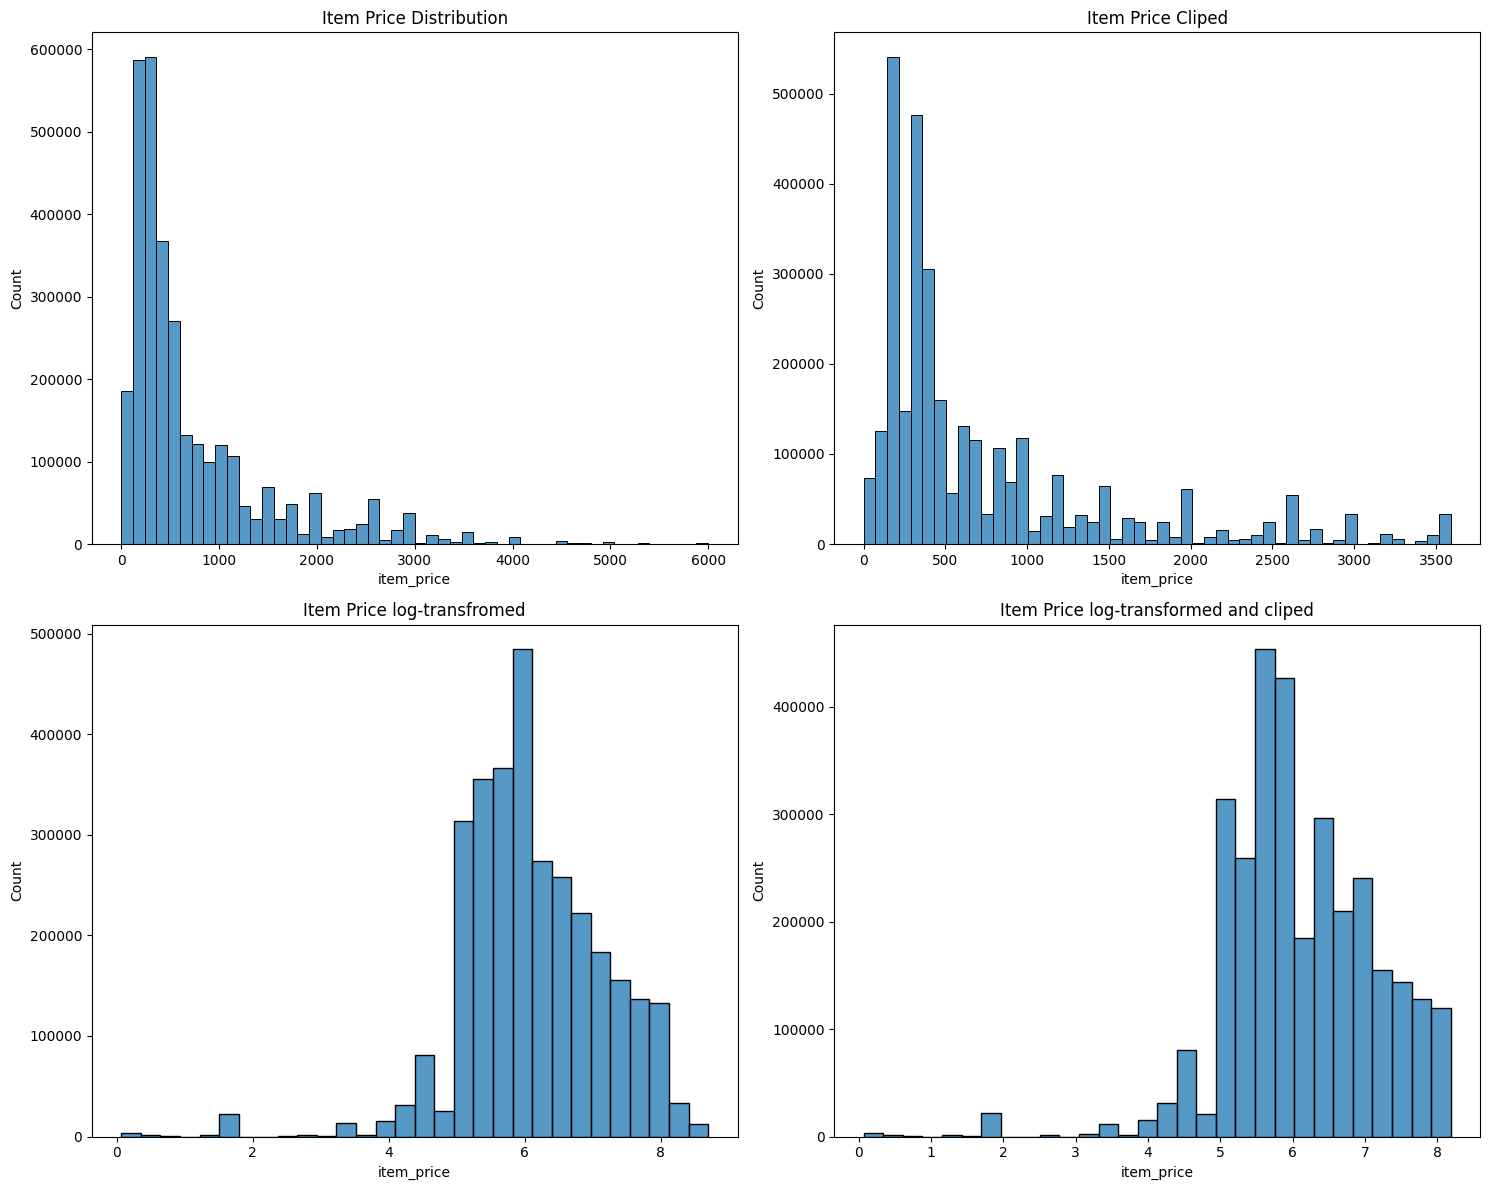

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15,12))
upper_bound = train['item_price'].quantile(0.99)

sns.histplot(train['item_price'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Item Price Distribution')

sns.histplot(train['item_price'].clip(0, upper_bound), bins=50, ax=axes[0,1])
axes[0,1].set_title('Item Price Cliped')

sns.histplot(np.log1p(train['item_price']), bins=30, ax=axes[1,0])
axes[1,0].set_title('Item Price log-transfromed')

sns.histplot(np.log1p(train['item_price'].clip(0, upper_bound)), bins=30, ax=axes[1,1])
axes[1,1].set_title('Item Price log-transformed and cliped')

plt.tight_layout()
plt.show()

Observations:
- General *item_price* does not give us much information. Though, we can see that most items' price is under 10k, but there is a little spike around 25k. Nevertheless the distribution is very skewed and the prices go up to 300k, which is abnormal.
- Clipping shows that 99% of items cost less than 6k. There is a huge spike at about 250-375 units, another spike at about 500-625, a group of prices uniformly distributed from ~650 up to ~1300. We can see another small groups but the main observation here is that prices mostly are not higher than 3k.
- Logarithm shows us a huge group of items with logarithm of about 5.75 - 6.25, representing price range of 300-500. The next big group is logarithm of 6.4 - 7.2, representing price range of about 550-1300. Another big group is logarithm of 4.5 - 5.5, representing price range of about 80 - 250. Yet there are still some more small groups and a strange spike at about 0 logarithm.
- Clipping and log-transfromation reveals some important information - the main range of item prices is about 50-3000. All the other stuff seems a bit strange and is probably outliers (or may be some luxurious or vise versa low-cost items).

From here we can make a general conclusion: despite the fact that the maximum price is around 300k, the most common prices are in range of 50-3k. Thus it gives the motivation to check the correlation between the *item_cnt_day* and *item_price*, supposely items with lower price can be sold more often.

**Feature Engineering Ideas**
- As it was observed prices are somehow 'clustered' and it may be useful to divide them into categorical groups(e.g. low, meidum, high, luxury), which might be a good indicator
- It makes sense to transform prices, i.e. apply log-transformation and scaling(via MinMaxScaler or StandardScaler). As it was mentioned before, this will reduce the overfitting effect and will simplify optimization

# 2. *item_cnt_day* - *item_price* correlation
It might be useful to understand whether the *item_cnt_day* is really dependant on *item_price*

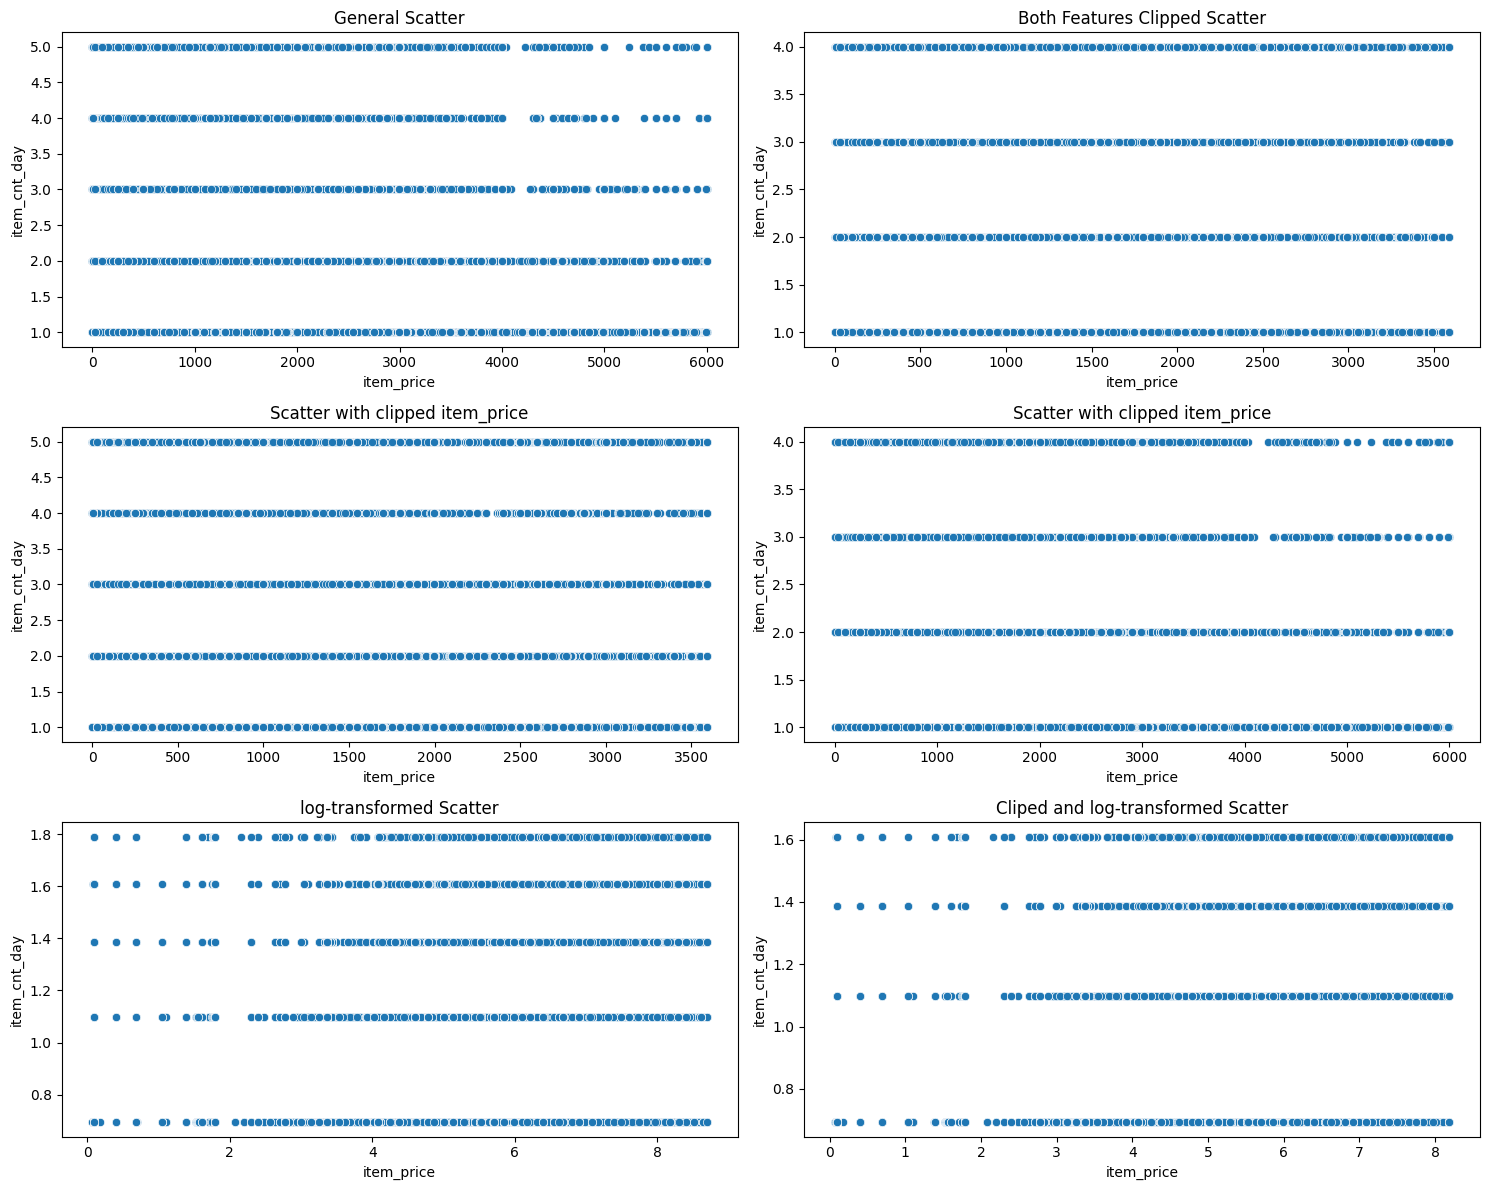

In [6]:
fig, axes = plt.subplots(3, 2, figsize = (15,12))
upper_bound_items, upper_bound_price = train['item_cnt_day'].quantile(0.99), train['item_price'].quantile(0.99)

sns.scatterplot(x=train['item_price'], y=train['item_cnt_day'], ax=axes[0,0])
axes[0,0].set_title('General Scatter')

sns.scatterplot(x=train['item_price'].clip(0, upper_bound_price), y=train['item_cnt_day'].clip(0, upper_bound_items), ax=axes[0,1])
axes[0,1].set_title('Both Features Clipped Scatter')

sns.scatterplot(x=train['item_price'].clip(0, upper_bound_price), y=train['item_cnt_day'], ax=axes[1,0])
axes[1,0].set_title('Scatter with clipped item_price')

sns.scatterplot(x=train['item_price'], y=train['item_cnt_day'].clip(0, upper_bound_items), ax=axes[1,1])
axes[1,1].set_title('Scatter with clipped item_price')

sns.scatterplot(x=np.log1p(train['item_price']), y=np.log1p(train['item_cnt_day']), ax=axes[2,0])
axes[2,0].set_title('log-transformed Scatter')

sns.scatterplot(x=np.log1p(train['item_price'].clip(0, upper_bound_price)), y=np.log1p(train['item_cnt_day'].clip(0, upper_bound_items)), ax=axes[2,1])
axes[2,1].set_title('Cliped and log-transformed Scatter')

plt.tight_layout()
plt.show()

Observations:
- Looking at general scatter we can make an assumption that there is really some kind of correlation between *item_price* and *item_cnt_day*. Small prices tend to be dominant and here we can see that most of items are compressed by 50k range. But there is one strange thing: 60k-300k range seems to be empty hmmmm???
- Clipping both features to their 99% percentiles does not show any specific correlations. May be it makes sense to clip features separately.
- Cliping price only reveals some interesting things. First of all we can see 2 extraordinary points near zero-price with high value of items bought (>2k and 1k). Moreover it's clearly seen that items with lower price (below 2k) tend to be bought more often. Then, they are dependant hmmm???
- Cliping *item_cnt_day* separately gives totally no information, therefore we can skip this scatter :)
- 2 final plots don't reveal any specific information as well

General conclusion is that there is no highly contrasted correlation (may be it's hidden) between *item_cnt_day* and *item_price*, except for the fact that items which cost less than 2k are more likely to be bought.

# 3. Time Series Research
It's now time for one of the most interesting parts - analyzing those strange extreme sales. General preassumption is that we are likely to have some special days (like holidays) when sales tend to go up.

First I'd love to know is there any changes in overall sales throughout time. Therefore doing `groupby` by *period* and summarizing *item_cnt_day* 

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


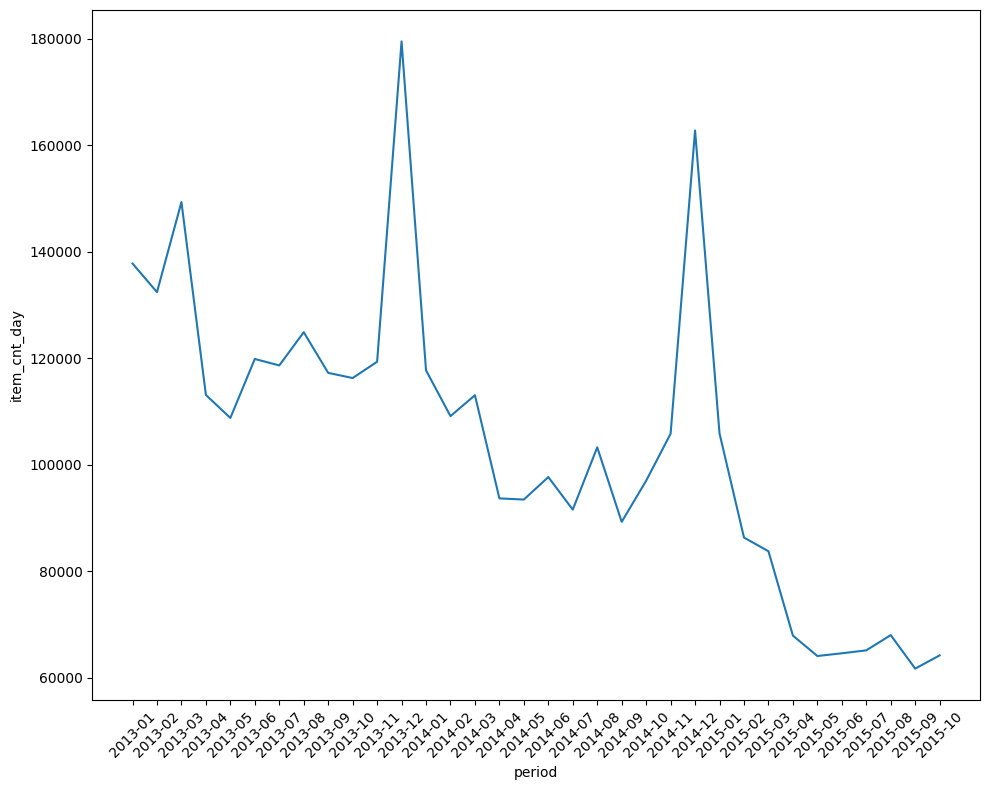

In [7]:
plt.figure(figsize=(10,8))
monthly_sales = train.groupby(['period']).agg({
    'item_cnt_day': 'sum'
}).reset_index()
sns.lineplot(x=monthly_sales['period'], y=monthly_sales['item_cnt_day'])
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

The initial time series analysis gives us some portion of interesting information

Observations:
- The start point is January 2013 and we can see that sales were about 130k items per month (all shops and all items), the end point is October 2015 and sales are about only 70k items per month. It's obvious that the sales dramatically decreased. So for now we can suppose that generally sales tend to go down.
- Probably the most important thing we can admit is those high peaks in October-November. There are probably a lot of holidays at this period therefore it can be a bit obvious that sales go up, though it's a piece of very important information for us to know.
- Then we can observe those peaks in January-February, might be some holidays as well but in 2015 there was a decrease at this period which is strange. I prefere not to think that 2013 and 2014 had high sales at this period due to holidays.
- Sales tend to be relatively low in spring and seem to go down. 
- Sales tend to go up during summer, might be due to some kind of vacations (or whatever).
- Winter is sort of a strange period, as something happens in December which makes sales go extremely low and I have no idea what it can be.

General conclusion: season of the year seems to be very important for us, as there are specific periods which tend to be repetitive.


**Feature Engineering Ideas**
- *month* might be very informative for us, but not for the model. We now know that sales tend to go extremely high in October-November, then go extremely low in December-January, and be relatively low during summer. The only problem is that we know that January goes right after December, unfortunattely the model will intepret December as 12 and January as 1. See, it's not obvious for the model that January goes right after December. Therefore I suppose we can benefit from circular month representation(i.e. sin and cos)
- We might need an indicatior or something like *is_holiday* for October-November period and *is_winter* for winter extreme decrease.

May be decomposing the time series might give us some external information

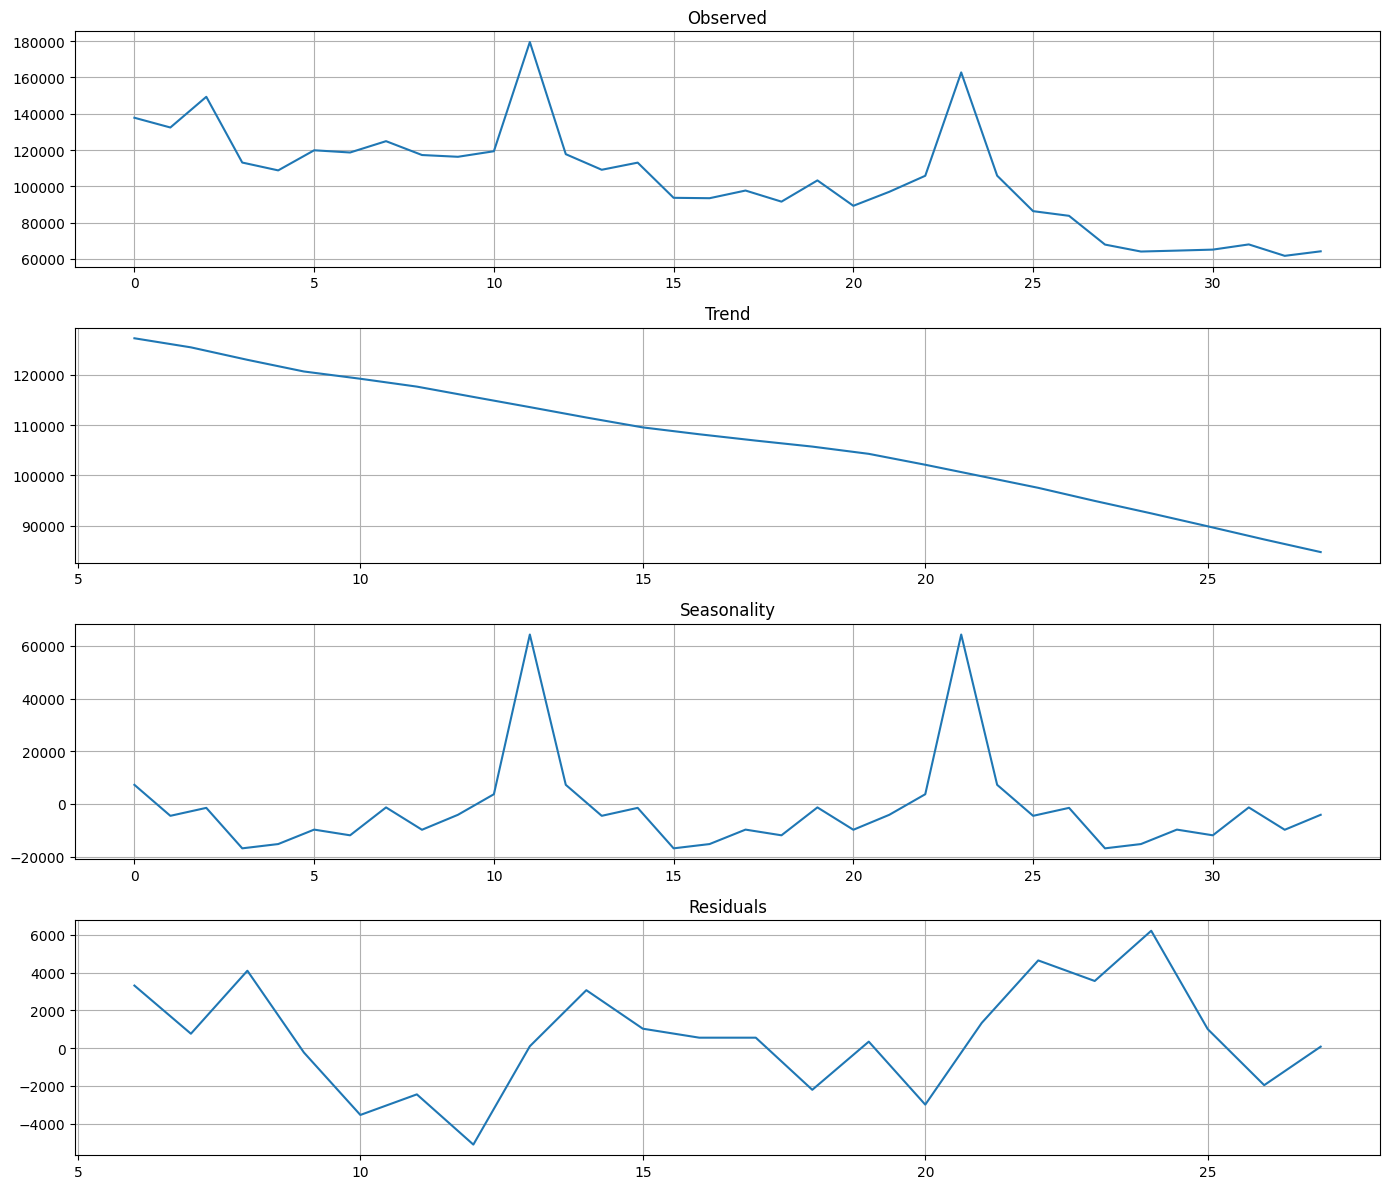

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(monthly_sales['item_cnt_day'], model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residuals')
for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

Observation:
- The starting point of the sales is 130k items per month, but the end point is under 90k. It's clear that sales tend to decrease over years, therefore we can notice a downgoing trend
- From seasonal component decomposition we learn that sales really have repetitiveness. They tend to go extremely high from month 10 to month 11, and then harshly go down in month 12. We can see a smooth increase before, starting in about month 6.
- The residuals have some kind of stochasticity, i.e. that seasonal and trend decomposition do not totally describe the time series(affected by special random events)

# 4. Stationarity check 

In [10]:
from statsmodels.tsa.stattools import adfuller

adf = adfuller(monthly_sales['item_cnt_day'])
print(f'p-value: {adf[1]}')

p-value: 0.13091376519879322


Observation:
- atrainuller p-value is 0.143 which means the time series is non-stationary (p-value <= 0.05 required), need to try deffirencing

In [11]:
adf = adfuller(monthly_sales['item_cnt_day'].diff().dropna())
print(f'p-value: {adf[1]}, used lag: {adf[2]}')

p-value: 4.122390848069216e-28, used lag: 10


Observation:
- Single differencing gives stationarity with p-value equal to 1.57 * 10^-25, additionally we now know that the lag used is 10 (might be important for further forecasting)


# 5. Yearly/Monthly/Weekly/Daily Dynamics 

In [12]:
yearly_train = train.groupby(['year']).agg({
    'item_cnt_day' : 'sum'
}).reset_index()

monthly_train = train.groupby(['month']).agg({
    'item_cnt_day' : 'sum'
}).reset_index()

weekly_train = train.groupby(['week']).agg({
    'item_cnt_day' : 'sum'
}).reset_index()

daily_train = train.groupby(['day_of_week']).agg({
    'item_cnt_day' : 'sum'
}).reset_index()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

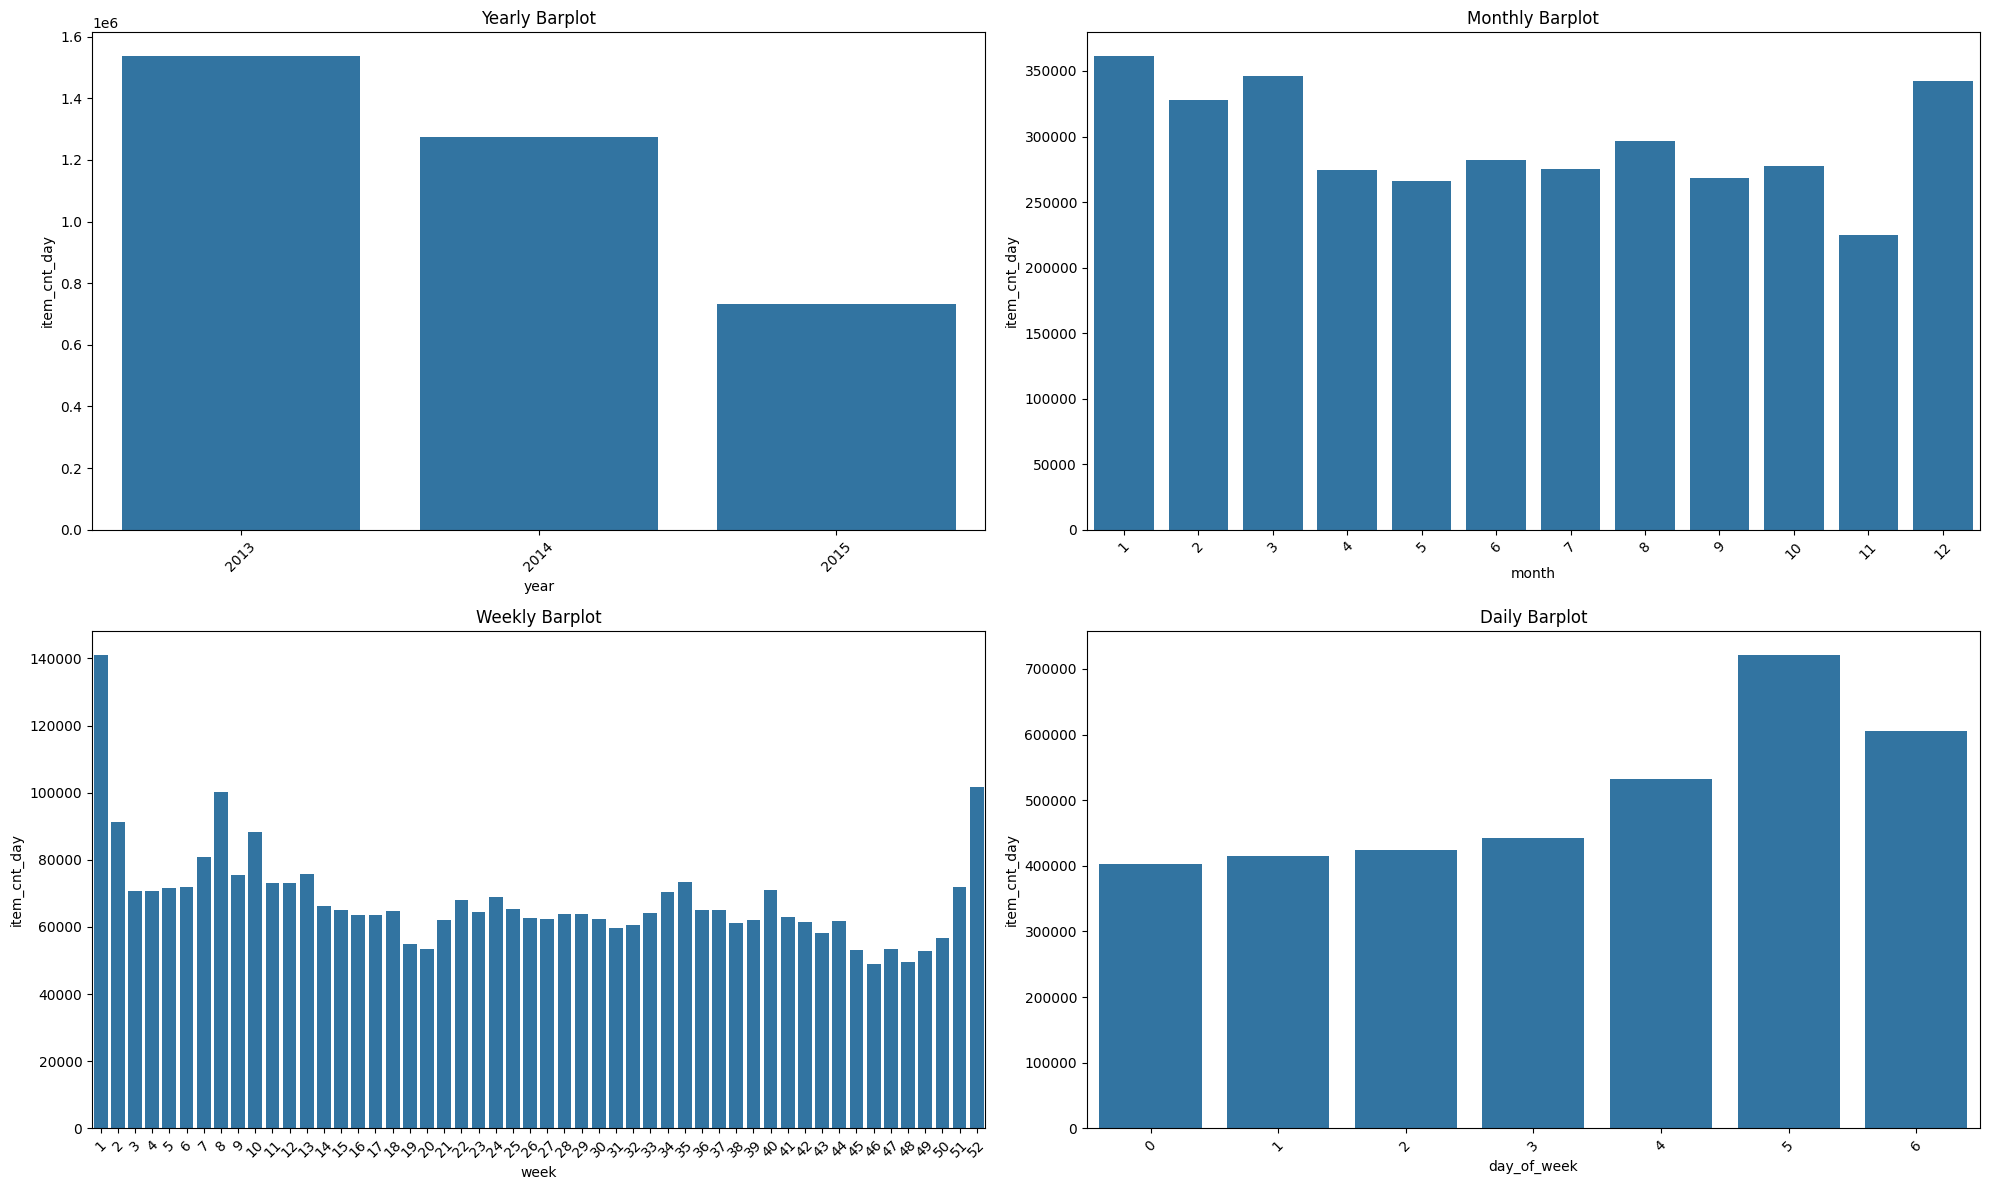

In [13]:
fig, axes = plt.subplots(2, 2, figsize = (20, 12))

sns.barplot(data=yearly_train, x='year', y='item_cnt_day', ax=axes[0,0])
axes[0,0].set_title('Yearly Barplot')
axes[0,0].tick_params('x', rotation=45)

sns.barplot(data=monthly_train, x='month', y='item_cnt_day', ax=axes[0,1])
axes[0,1].set_title('Monthly Barplot')
axes[0,1].tick_params('x', rotation=45)


sns.barplot(data=weekly_train, x='week', y='item_cnt_day', ax=axes[1,0])
axes[1,0].set_title('Weekly Barplot')
axes[1,0].tick_params('x', rotation=45)


sns.barplot(data=daily_train, x='day_of_week', y='item_cnt_day', ax=axes[1,1])
axes[1,1].set_title('Daily Barplot')
axes[1,1].tick_params('x', rotation=45)


plt.tight_layout()
plt.show()


Observation:
- Once again yearly barplot proves that sales have a tendency to decrease over the years
- Monthly barplot shows that over months sales are almost equal, though we have slight peaks in the beginning of the year (January-March) and in the end of the year (December)
- From weekly barplot we know that sales are also almost uniform through weeks, though there are slight peaks at week 8, week 40 and week 52 and a huge peek at week 1, which can also be important for the model to learn
- Daily barplot displays peaks on weekends (which is probably obvious), and most of purchases are made on Saturday

**Feature Engineering Ideas**
- I insist on creating cyclic feature (sin or cos) for *month* and *week* so that the model knows that January and December are closely related, as well as week 52 and week 1
- It might be useful to create *is_weekend* indicator, representing Saturday and Sunday (as most sales occur on this days)

    P.S. may be Friday should be taken into account as well
    
- Probably we now can drop *date_block_num* as it's not informative anymore

# 6. Categories Popularity 

In [14]:
gen_cats = train['item_category_name'].str.split('-').str[0]
train['gen_cat'] = gen_cats

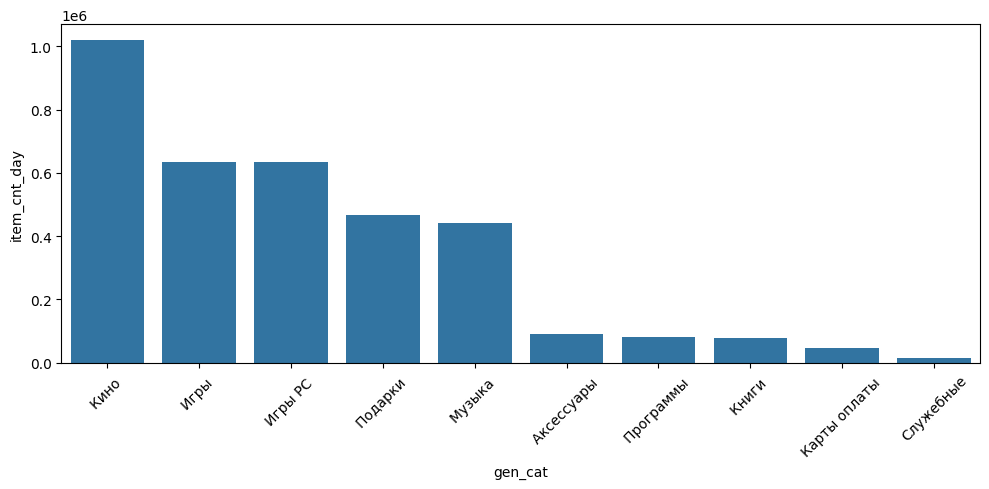

In [15]:
top_10_categories = train.groupby('gen_cat')['item_cnt_day'].sum().nlargest(10)
plt.figure(figsize=(10,5))
sns.barplot(top_10_categories)
plt.tick_params('x', rotation = 45)
plt.tight_layout()
plt.show()

Observation:
- At this section we see top-10 categories and can extract some interesting information. First of all we see a huge difference between top-5 and top-6 category (it's about 4 times as big), therefore we probably should get a better look at top-5 categories
- Here we clearly see that 'кино' is the most dominant category, ['игры рс','игры','подарки'] are sold almost in same amounts and 'музыка' is least sold in top-5 categories

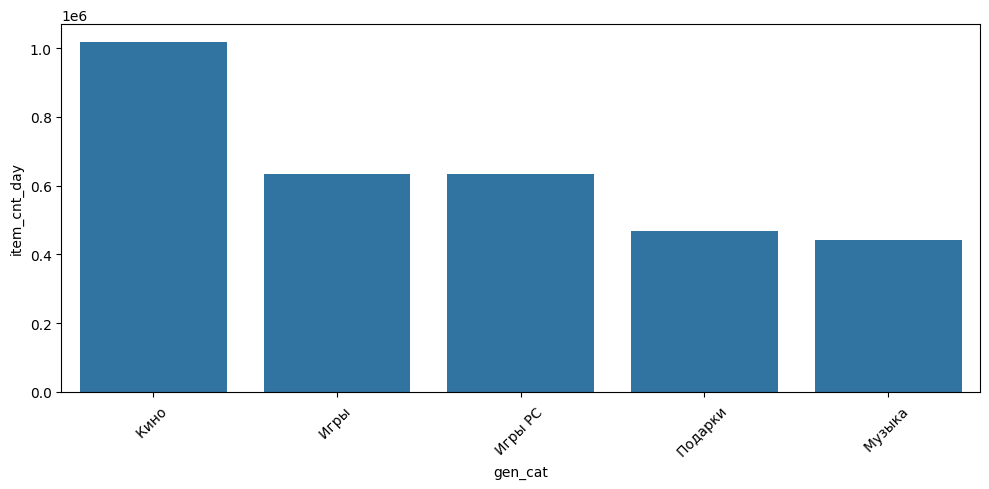

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(top_10_categories[:5])
plt.tick_params('x', rotation = 45)
plt.tight_layout()
plt.show()

**Feature Engineering Ideas**
- I can assume that *gen_cat* feature seems to be more informative than original *item_category_name*, therefore I'd prefere to replace the second with the first one respectively
- Additionally we can probably benefit from some kind of *cat_popularity* indicator (i.e. ['most_popular', 'popular', 'less_popular', 'least_popular'])

# 7. Items Popularity
At this point, as we now know something about categories, it may be usefull for us to see if there are some specific items most likely to be bought

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


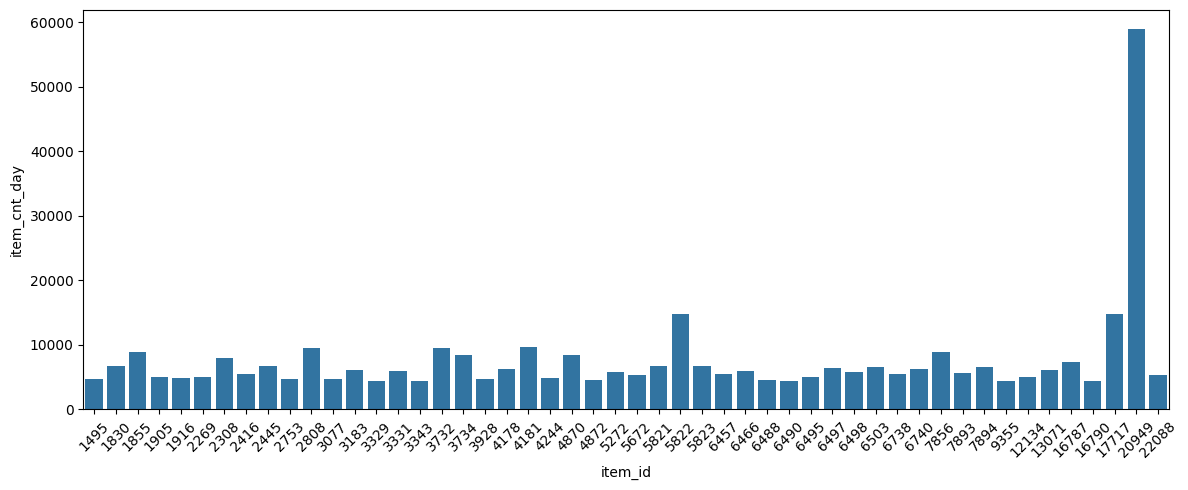

In [17]:
top_50_items = train.groupby(['item_id']).agg({
    'item_cnt_day' : 'sum'
}).reset_index()
top_50_items = top_50_items.sort_values(by = 'item_cnt_day', ascending = False)
plt.figure(figsize=(12,5))
sns.barplot(x=top_50_items['item_id'][:50], y=top_50_items['item_cnt_day'][:50])
plt.tick_params('x', rotation = 45)
plt.tight_layout()
plt.show()

Observation:
- Plotting top-50 bought items does not seem very informative, though I made an attempt to plot top-200 and top-500 items and, believe me, it was awfull to see ^-^. Nevertheless we can see that items in top-50 are in most cases bought uniformly. Though there is one strange item bought in general more than 175k times. tbh I'm not able to make any specific conclusions on this matter.

# 8. Shops Popularity
The last thing of popularity to be checked is shops, and I feel there can be something interesting

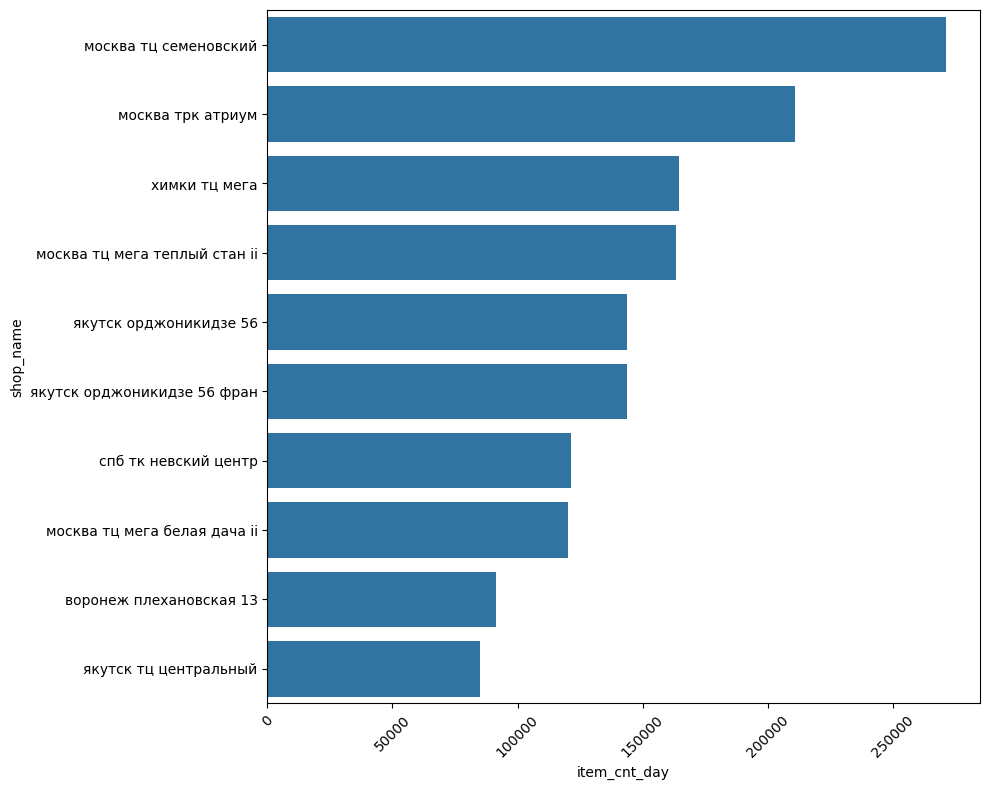

In [18]:
top_shops = train.groupby('shop_name')['item_cnt_day'].sum()
plt.figure(figsize=(10, 8))
sns.barplot(data=top_shops.nlargest(10), orient='h')
plt.tick_params('x', rotation=45)
plt.tight_layout()
plt.show()

Observations:
- As expected we can see some kind of 'popularity ranking' here. We see 2 stand outs: 'семеновский' and 'атриум' both in 'москва'. We can see some less popular shops and least popular in top-10. As we have only 60 unique shop names, let's better do the barplot for all the shops to the the general picture

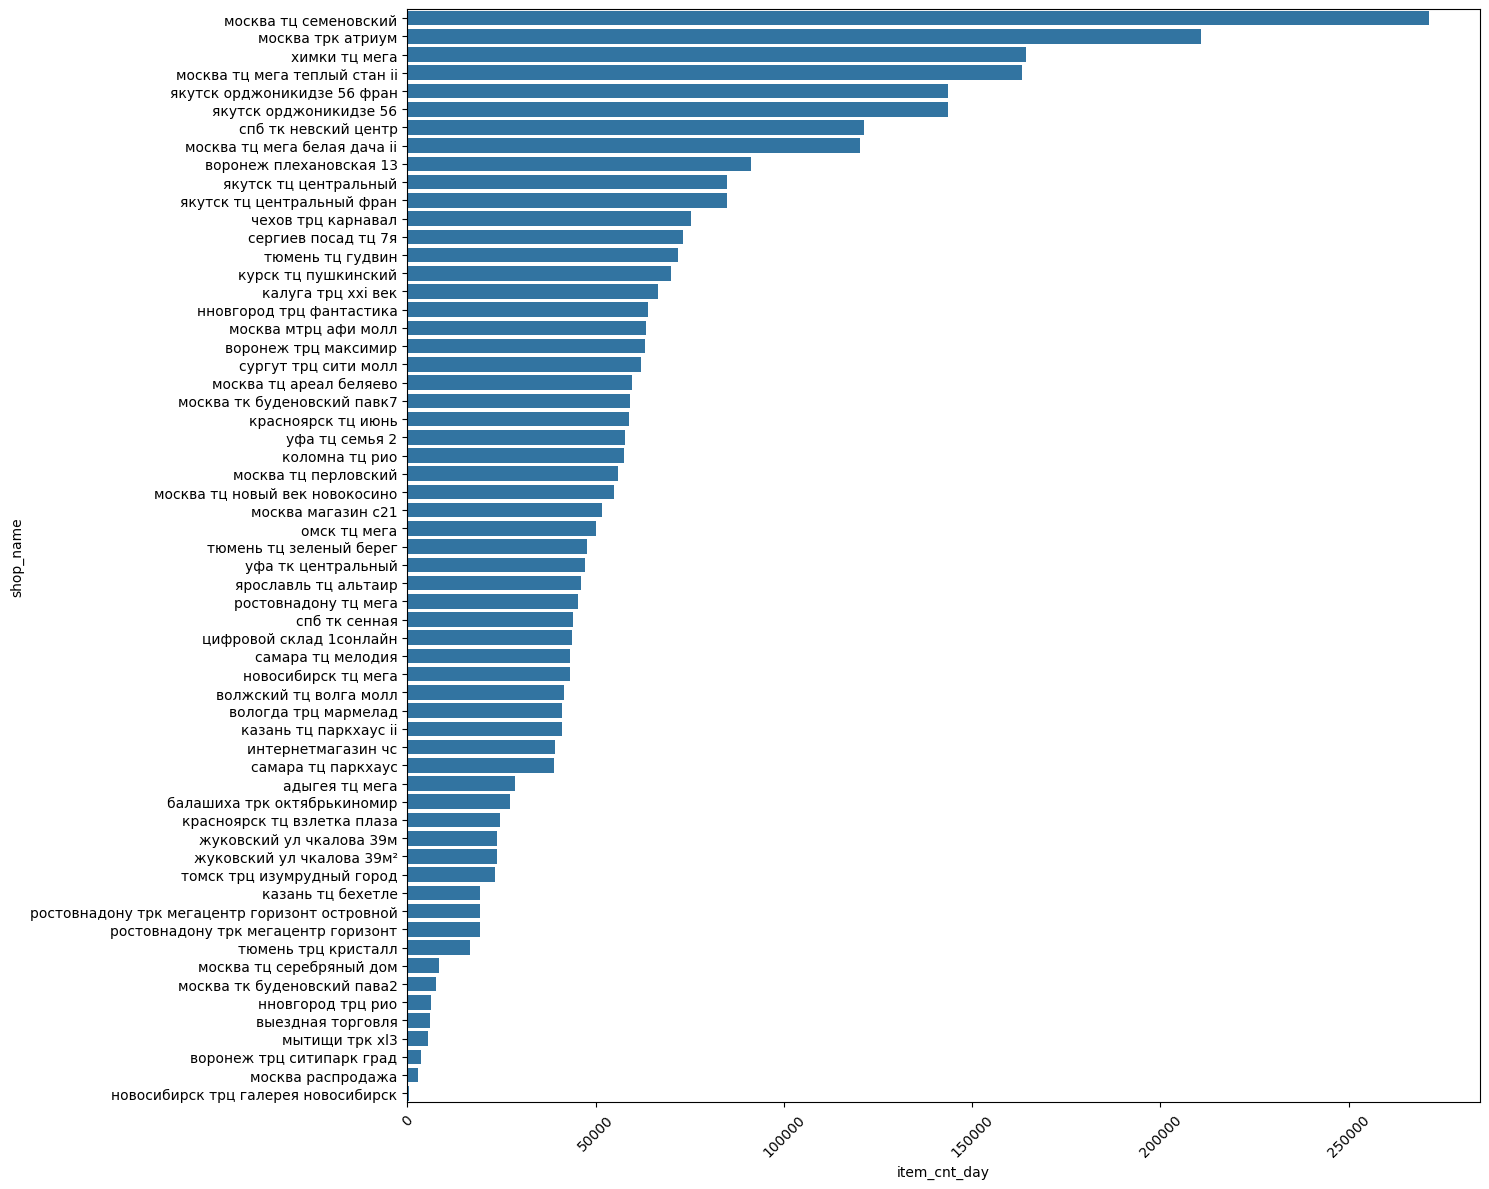

In [19]:
plt.figure(figsize=(15, 12))
sns.barplot(data=top_shops.sort_values(ascending=False), orient='h')
plt.tick_params('x', rotation=45)
plt.tight_layout()
plt.show()

- Oh yes we now clearly see that shops can be included in some 'popularity clusters'. And what is interesting - there are shops with 0 sells hmmm? Let's figure it out

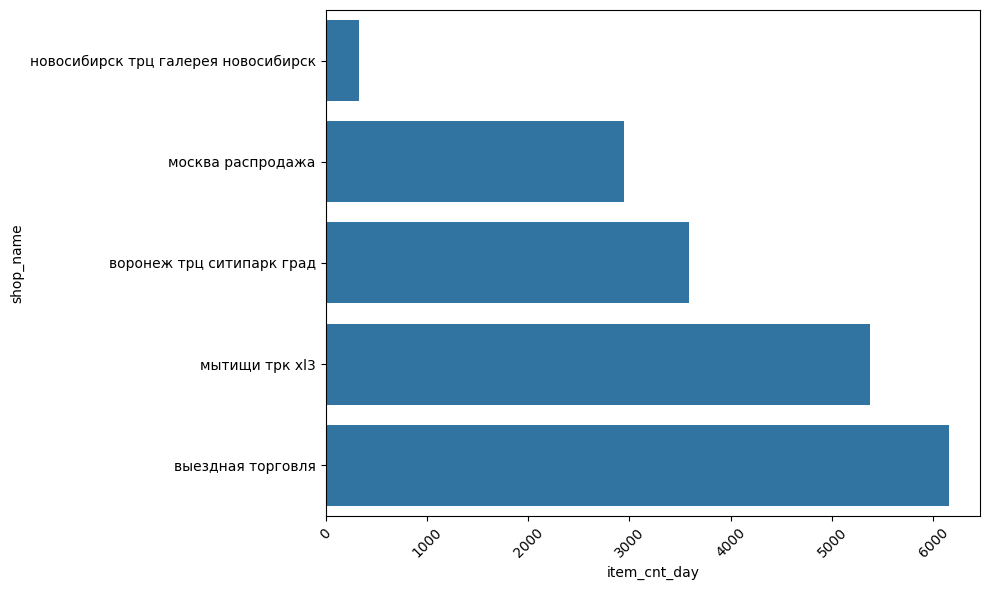

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_shops.nsmallest(5), orient='h')
plt.tick_params('x', rotation=45)
plt.tight_layout()
plt.show()

- Well in the previous plot the *figsize* value was just not big enough to see clearly, but now we can see that there are no shops with zero-sells. Anyways there are 2 shops with total sells less than 1k.

General conclusion: *shop_name* feature seems to have effect on purchases frequency, yet I dare to assume that the point is not just the shop, but the city it's located in. It's to be figured out later on.

**Feature Engeneering Ideas**
- Some kind of *shop_popularity* indicator might be useful(e.g. ['very_popular', 'popular', 'less_popular', 'unpopular']) 

# 9. City Popularity
Right after shop popularity analysis I came across an idea that may be it's not that shop popularity as city popularity, so let's plot top-city barplot

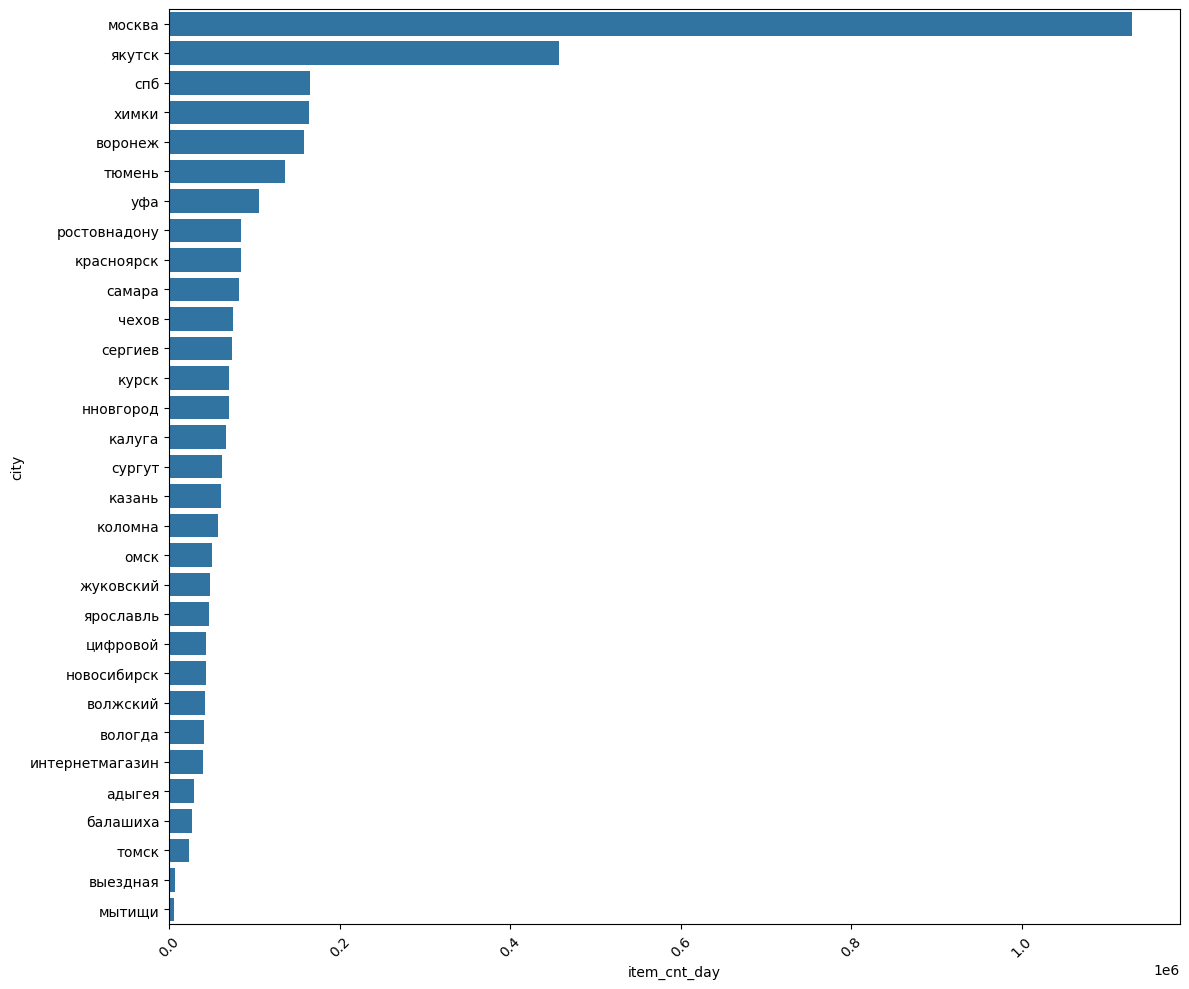

In [21]:
top_cities = train.groupby('city')['item_cnt_day'].sum()
plt.figure(figsize=(12, 10))
sns.barplot(data=top_cities.sort_values(ascending=False), orient='h')
plt.tick_params('x', rotation=45)
plt.tight_layout()
plt.show()

Observations:
- Wow! 'Москва' is a freaking selling giant with total sales of about 1.3kk items, that's huge. Well generally I have 2 assumptions. The first one is that people in 'Москва' tend to buy most of all. The second one is that 'Москва' has the largest number of shops. Let's check it out.

In [22]:
moskva_entries = train.loc[train['shop_name'].str.contains("москва", case=False), 'shop_name'].nunique()
yakutsk_entries = train.loc[train['shop_name'].str.contains("якутск", case=False), 'shop_name'].nunique()
moskva_entries, yakutsk_entries

(13, 4)

Observation:
- Well for clarity I decided to provide the number of shops containing top-2 city in it's names. The difference is huge. 'Москва' has 13 entries(which is almost 22% of all shops), whereas top-2 'якутск' has only 4 entries. I'm now really curious to know whether the number of shops effects or not.

In [23]:
from collections import defaultdict
cities_in_shops = defaultdict()
cities = list(train['city'].unique())

for city in cities:
    cities_in_shops[city] = train.loc[train['shop_name'].str.contains(city, case=False), 'shop_name'].nunique()


In [24]:
sorted(cities_in_shops.items(), key=lambda kv:kv[1], reverse=True)

[('москва', 13),
 ('якутск', 4),
 ('воронеж', 3),
 ('тюмень', 3),
 ('ростовнадону', 3),
 ('красноярск', 2),
 ('жуковский', 2),
 ('казань', 2),
 ('уфа', 2),
 ('нновгород', 2),
 ('спб', 2),
 ('омск', 2),
 ('самара', 2),
 ('новосибирск', 2),
 ('ярославль', 1),
 ('курск', 1),
 ('волжский', 1),
 ('адыгея', 1),
 ('балашиха', 1),
 ('коломна', 1),
 ('калуга', 1),
 ('интернетмагазин', 1),
 ('чехов', 1),
 ('химки', 1),
 ('сургут', 1),
 ('сергиев', 1),
 ('вологда', 1),
 ('цифровой', 1),
 ('выездная', 1),
 ('томск', 1),
 ('мытищи', 1)]

Observation:
- Well it seems like the number of shops in the city does not really matter, well than 'москва' is just a selling mutant ^-^

**Feature Engineering Ideas**
- Let's assume creating one more indicator for city popularity (e.g. ['very_popular', 'popular', 'unpopular']). The only thing to deal with is 'Москва', as it can spoil the division (by adding bias)

# 10. General Correlation Analysis

<Axes: >

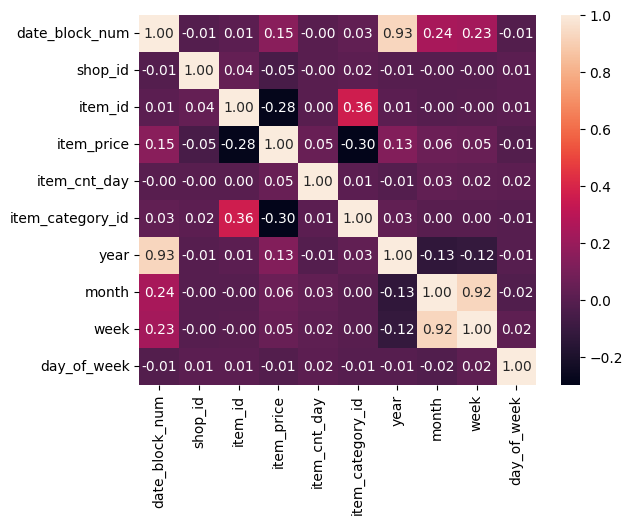

In [25]:
corr = train.corr(numeric_only=True)
sns.heatmap(corr, fmt = '.2f', annot=True)

Observation:
- Let's begin with huge positive correlations. The first thing we see is *date_block_num* - *year* correlation(0.93), which is obvious as month order(as it is presented in this feature) is dependent on year. Then we see *item_id* - *item_category_id* correlation(0.37), which does not make any sense and should be fixed. Next we can see *month* - *date_block_num* correlation(0.24) and *week*-*date_block_num* correlation(0.23), and as it was mentioned far previously *date_block_num* is not informative and should be deleted so we should not pay attention at this correlation. Then we see *month* - *week*(0.93) correlation, which occurs because of the representation (both features are presented as consecutive integers)
- Now let's explore negative correlations. We see that slight *item_id* and *item_price* negative correlation(-0.13) which is actually ridicilous (higher *item_id* value = lower *item_price* value hmm???). Then we see *item_price* - *item_category_id* negative correlation(-0.25) which also does not make any sense. The funniest thing is *year* - *month* and *year* - *week* negative correlation (later years represent earlier months and weeks huh????)

**Feature Engineering Ideas**
- I guess at this point I can highlight those features I suppose to be not informative enough or may be even useless: *date_block_num*, *shop_id*, *item_id*, *item_category_id*. Preferable action is to drop these features and replace them with some of those proposed all over the notebook